In [34]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
import os

CSV_SCORES   = '../results/sentiment_analysis/yelp_academic_dataset_review_scored.csv'
CSV_BUSINESS = '../data/csv/yelp_academic_dataset_business.csv'

NRC_COLS = [
    'nrc_anger', 'nrc_anticipation', 'nrc_disgust', 'nrc_fear',
    'nrc_joy', 'nrc_negative', 'nrc_positive', 'nrc_sadness',
    'nrc_surprise', 'nrc_trust', 'nrc_compound'
]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [16]:
df_scores = pl.scan_csv(CSV_SCORES, ignore_errors=True).select(['business_id', 'stars', 'date', 'text', 'vader_score', 'afinn_score'] + NRC_COLS)

print(df_scores.collect_schema().names())

Columnas cargadas:
['business_id', 'stars', 'date', 'text', 'vader_score', 'afinn_score', 'nrc_anger', 'nrc_anticipation', 'nrc_disgust', 'nrc_fear', 'nrc_joy', 'nrc_negative', 'nrc_positive', 'nrc_sadness', 'nrc_surprise', 'nrc_trust', 'nrc_compound']


In [15]:
df_agg = (
    df_scores
    .with_columns(
        (pl.col('text').str.count_matches(" ") + 1).alias('word_count')
    )
    .group_by('business_id')
    .agg([
            pl.len().alias('review_count_scores'),
            pl.col('vader_score').mean().alias('vader_mean'),
            pl.col('afinn_score').mean().alias('afinn_mean'),
            pl.col('word_count').mean().alias('word_count_mean'),
            pl.col('stars').var().alias('stars_variance'),
            pl.col('stars').mean().alias('stars_review_mean'),
            (
                pl.col('vader_score').sort_by('date').tail(pl.len() // 2).mean() - 
                pl.col('vader_score').sort_by('date').head(pl.len() // 2).mean()
            ).alias('vader_trend')
        ] + [
            pl.col(col).mean().alias(f'{col}_mean')
            for col in NRC_COLS
        ])
)

print(df_agg.collect().shape)

(150346, 19)


In [21]:
df_business = (pl.scan_csv(CSV_BUSINESS, ignore_errors=True).select(['business_id', 'stars', 'review_count', 'is_open', 'categories', 'city', 'state']))

df_model = (df_agg.join(df_business, on='business_id', how='inner').collect(engine='streaming'))

print(f'Dataset final: {df_model.shape}')

Dataset final: (150243, 25)


Distribución de is_open:
  Cerrado (0): 30,640 (20.4%)
  Abierto (1): 119,603 (79.6%)


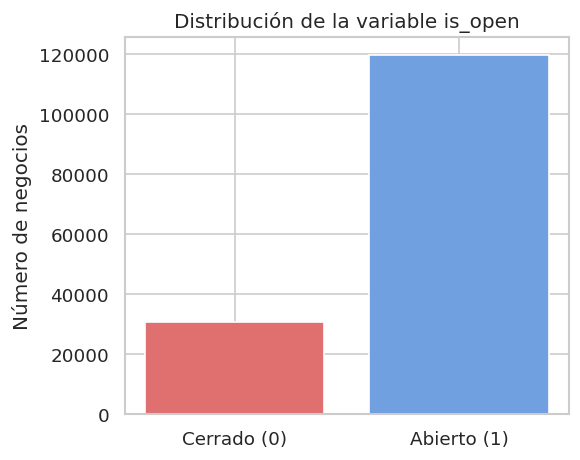

In [22]:
counts = df_model['is_open'].value_counts().sort('is_open')
total  = df_model.shape[0]

print('Distribución de is_open:')
for row in counts.iter_rows(named=True):
    label = 'Abierto' if row['is_open'] == 1 else 'Cerrado'
    print(f'  {label} ({row["is_open"]}): {row["count"]:,} ({row["count"] / total * 100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Cerrado (0)', 'Abierto (1)'],
       counts['count'].to_list(),
       color=['#e07070', '#70a0e0'])
ax.set_title('Distribución de la variable is_open')
ax.set_ylabel('Número de negocios')
plt.tight_layout()
plt.show()

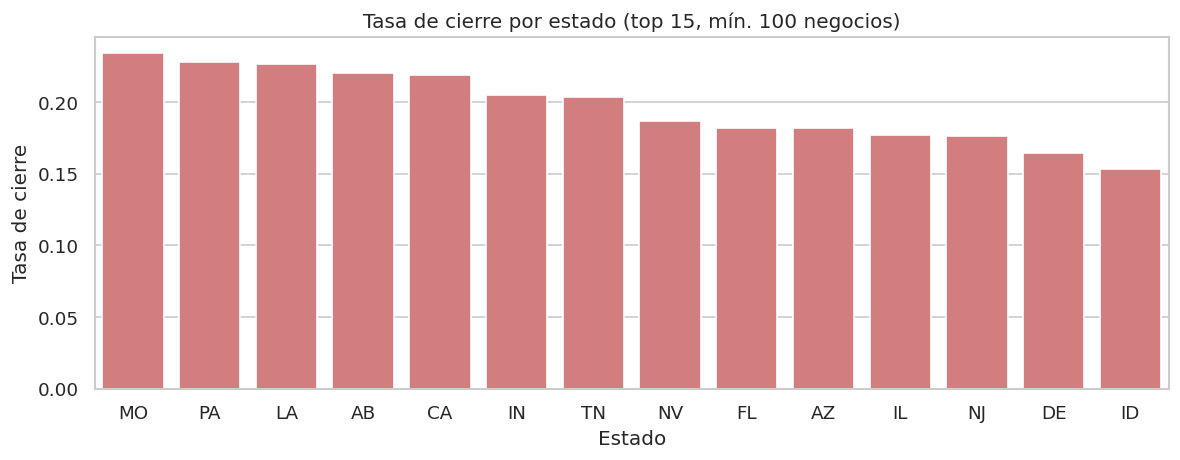

In [23]:
cierre_estado = (
    df_model
    .group_by('state')
    .agg([
        pl.len().alias('total'),
        (pl.col('is_open') == 0).sum().alias('cerrados'),
    ])
    .with_columns((pl.col('cerrados') / pl.col('total')).alias('tasa_cierre'))
    .filter(pl.col('total') >= 100)
    .sort('tasa_cierre', descending=True)
    .head(15)
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=cierre_estado, x='state', y='tasa_cierre', ax=ax, color='#e07070')
ax.set_title('Tasa de cierre por estado (top 15 > 100 negocios)')
ax.set_ylabel('Tasa de cierre')
ax.set_xlabel('Estado')
plt.tight_layout()
plt.show()

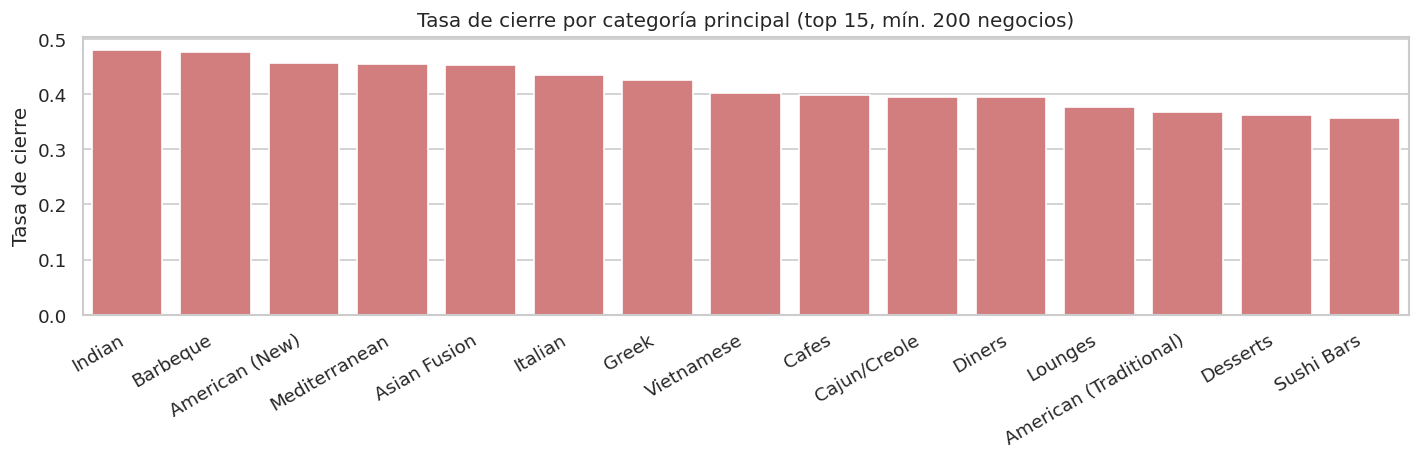

In [24]:
cierre_cat = (
    df_model
    .with_columns(
        pl.col('categories').str.split(', ').list.first().alias('main_category')
    )
    .group_by('main_category')
    .agg([
        pl.len().alias('total'),
        (pl.col('is_open') == 0).sum().alias('cerrados'),
    ])
    .with_columns((pl.col('cerrados') / pl.col('total')).alias('tasa_cierre'))
    .filter(pl.col('total') >= 200)
    .sort('tasa_cierre', descending=True)
    .head(15)
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=cierre_cat, x='main_category', y='tasa_cierre', ax=ax, color='#e07070')
ax.set_title('Tasa de cierre por categoría principal (top 15 > 200 negocios)')
ax.set_ylabel('Tasa de cierre')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

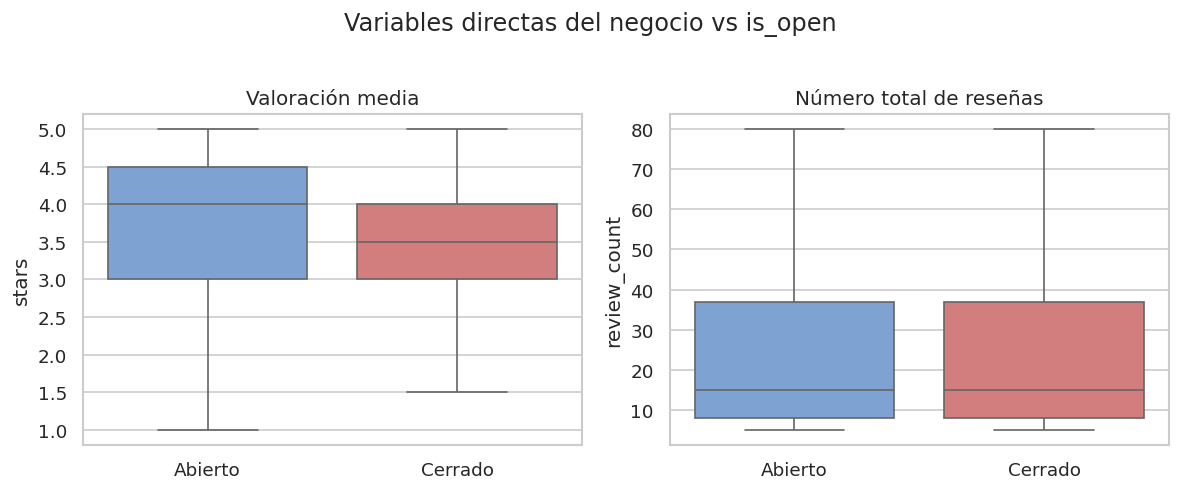

In [40]:
df_pd = df_model.to_pandas()
df_pd['is_open_label'] = df_pd['is_open'].map({1: 'Abierto', 0: 'Cerrado'})

features_negocio = {
    'stars':        'Valoración media',
    'review_count': 'Número total de reseñas',
}

fig, axes = plt.subplots(1, len(features_negocio), figsize=(10, 4))

for ax, (col, title) in zip(axes, features_negocio.items()):
    sns.boxplot(
        data=df_pd, 
        x='is_open_label', 
        y=col, 
        ax=ax,
        hue='is_open_label',
        legend=False,
        palette={'Abierto': '#70a0e0', 'Cerrado': '#e07070'},
        showfliers=False
    )
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Variables directas del negocio vs is_open', y=1.02)
plt.tight_layout()
plt.show()

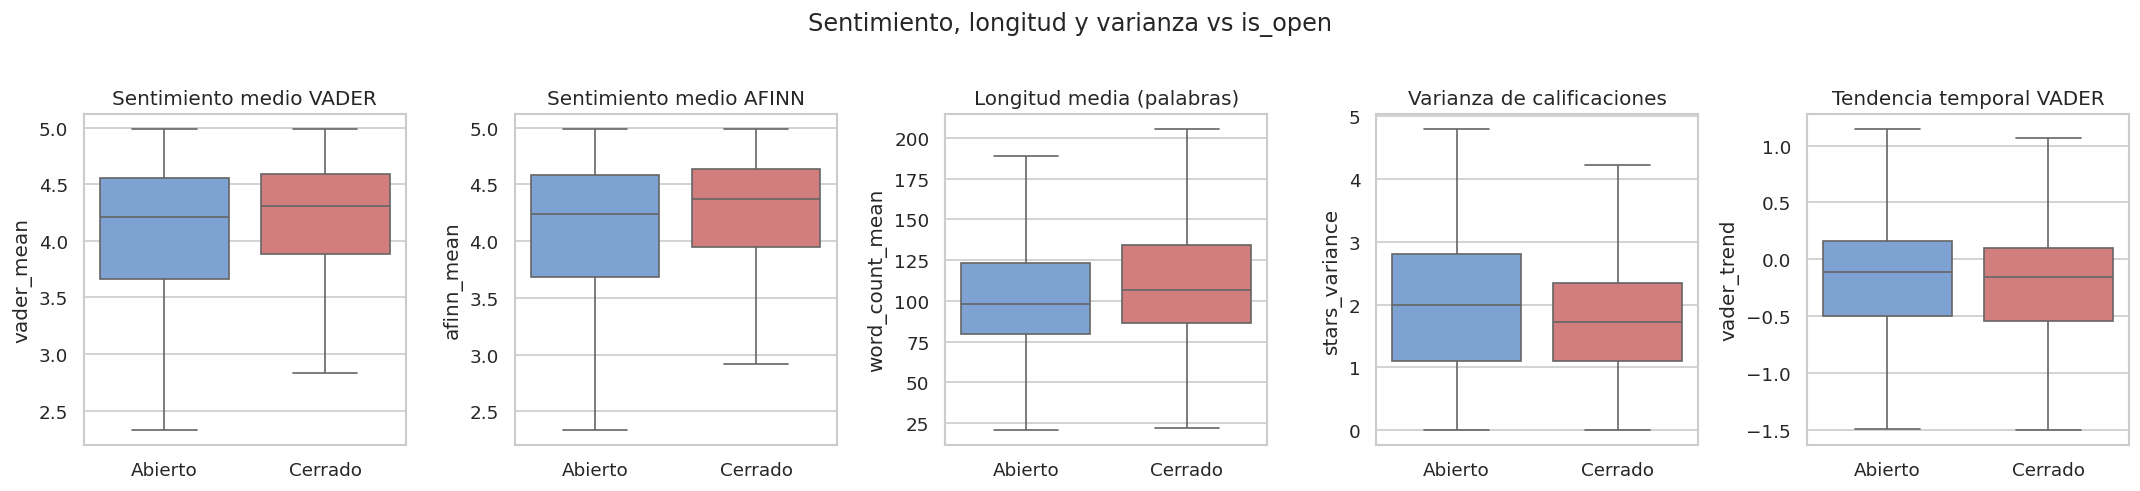

In [27]:
features_resenas = {
    'vader_mean':      'Sentimiento medio VADER',
    'afinn_mean':      'Sentimiento medio AFINN',
    'word_count_mean': 'Longitud media (palabras)',
    'stars_variance':  'Varianza de calificaciones',
    'vader_trend':     'Tendencia temporal VADER',
}

fig, axes = plt.subplots(1, len(features_resenas), figsize=(18, 4))

for ax, (col, title) in zip(axes, features_resenas.items()):
    sns.boxplot(
        data=df_pd,
        x='is_open_label',
        y=col,
        ax=ax,
        hue='is_open_label',
        legend=False,
        palette={'Abierto': '#70a0e0', 'Cerrado': '#e07070'},
        showfliers=False
    )
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Sentimiento, longitud y varianza vs is_open', y=1.02)
plt.tight_layout()
plt.show()

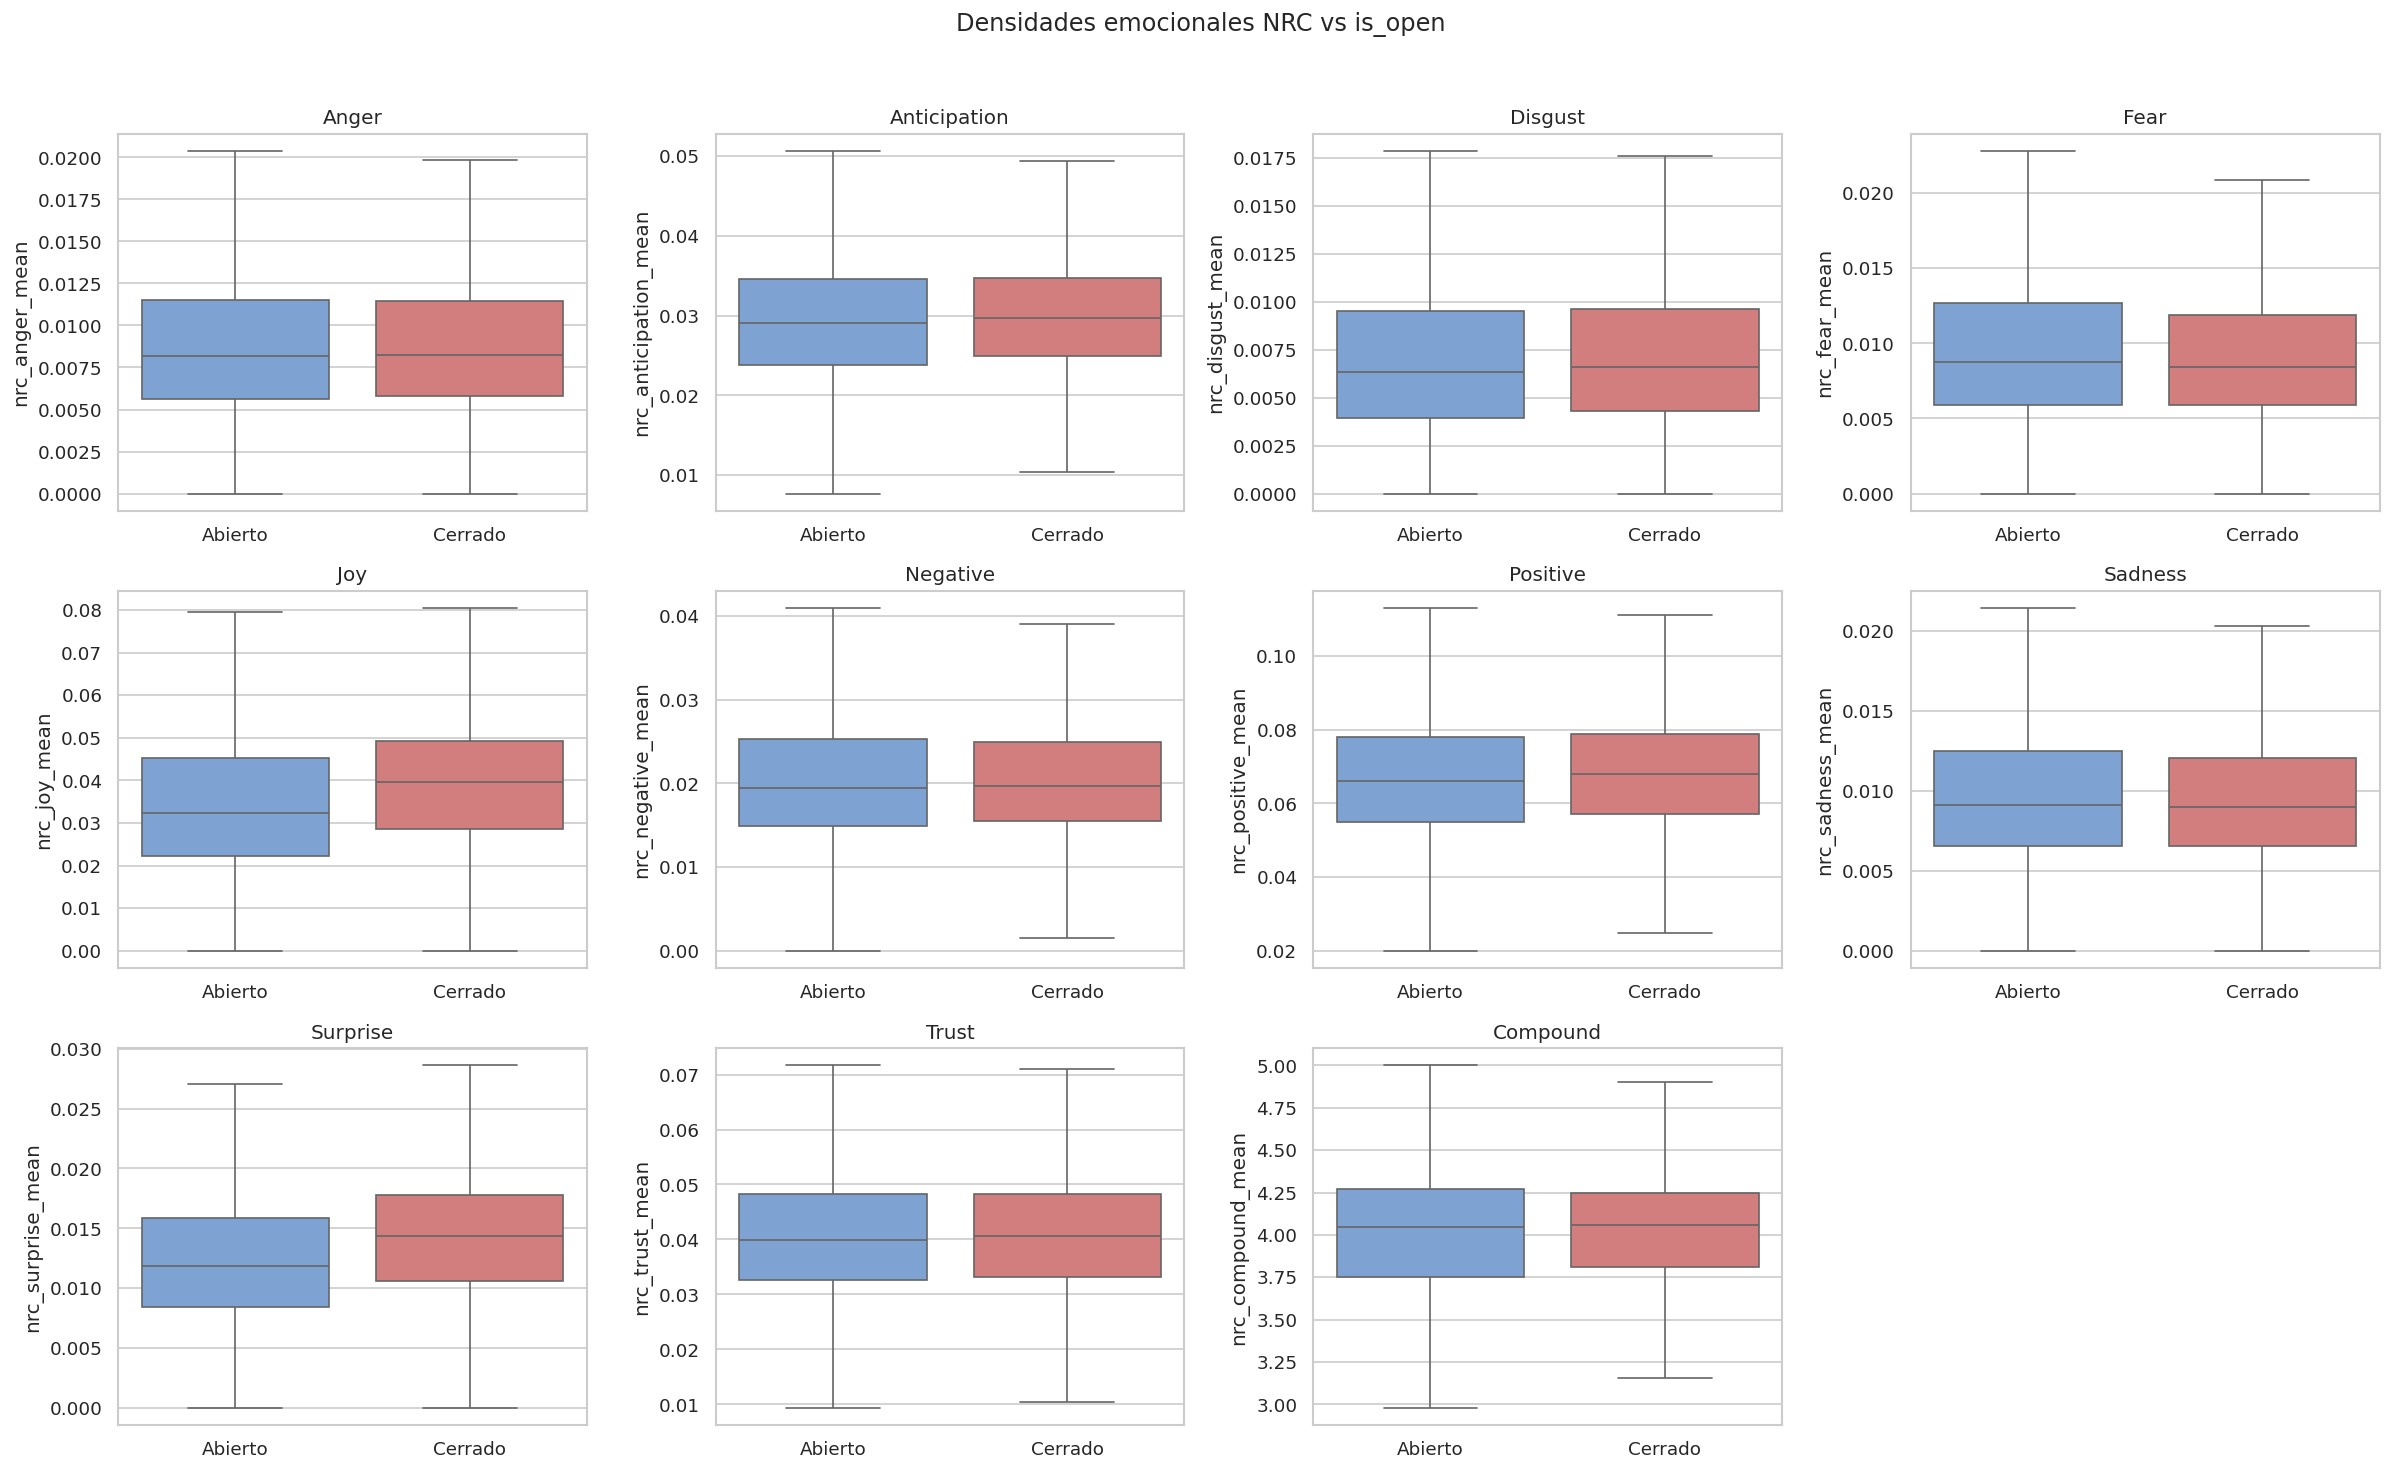

In [28]:
nrc_mean_cols = [f'{c}_mean' for c in NRC_COLS]
nrc_titles    = [c.replace('nrc_', '').capitalize() for c in NRC_COLS]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(nrc_mean_cols, nrc_titles)):
    sns.boxplot(
        data=df_pd, 
        x='is_open_label', 
        y=col, 
        ax=axes[i],
        hue='is_open_label',
        legend=False,
        palette={'Abierto': '#70a0e0', 'Cerrado': '#e07070'},
        showfliers=False
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('')

for j in range(len(nrc_mean_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidades emocionales NRC vs is_open', y=1.02)
plt.tight_layout()
plt.show()

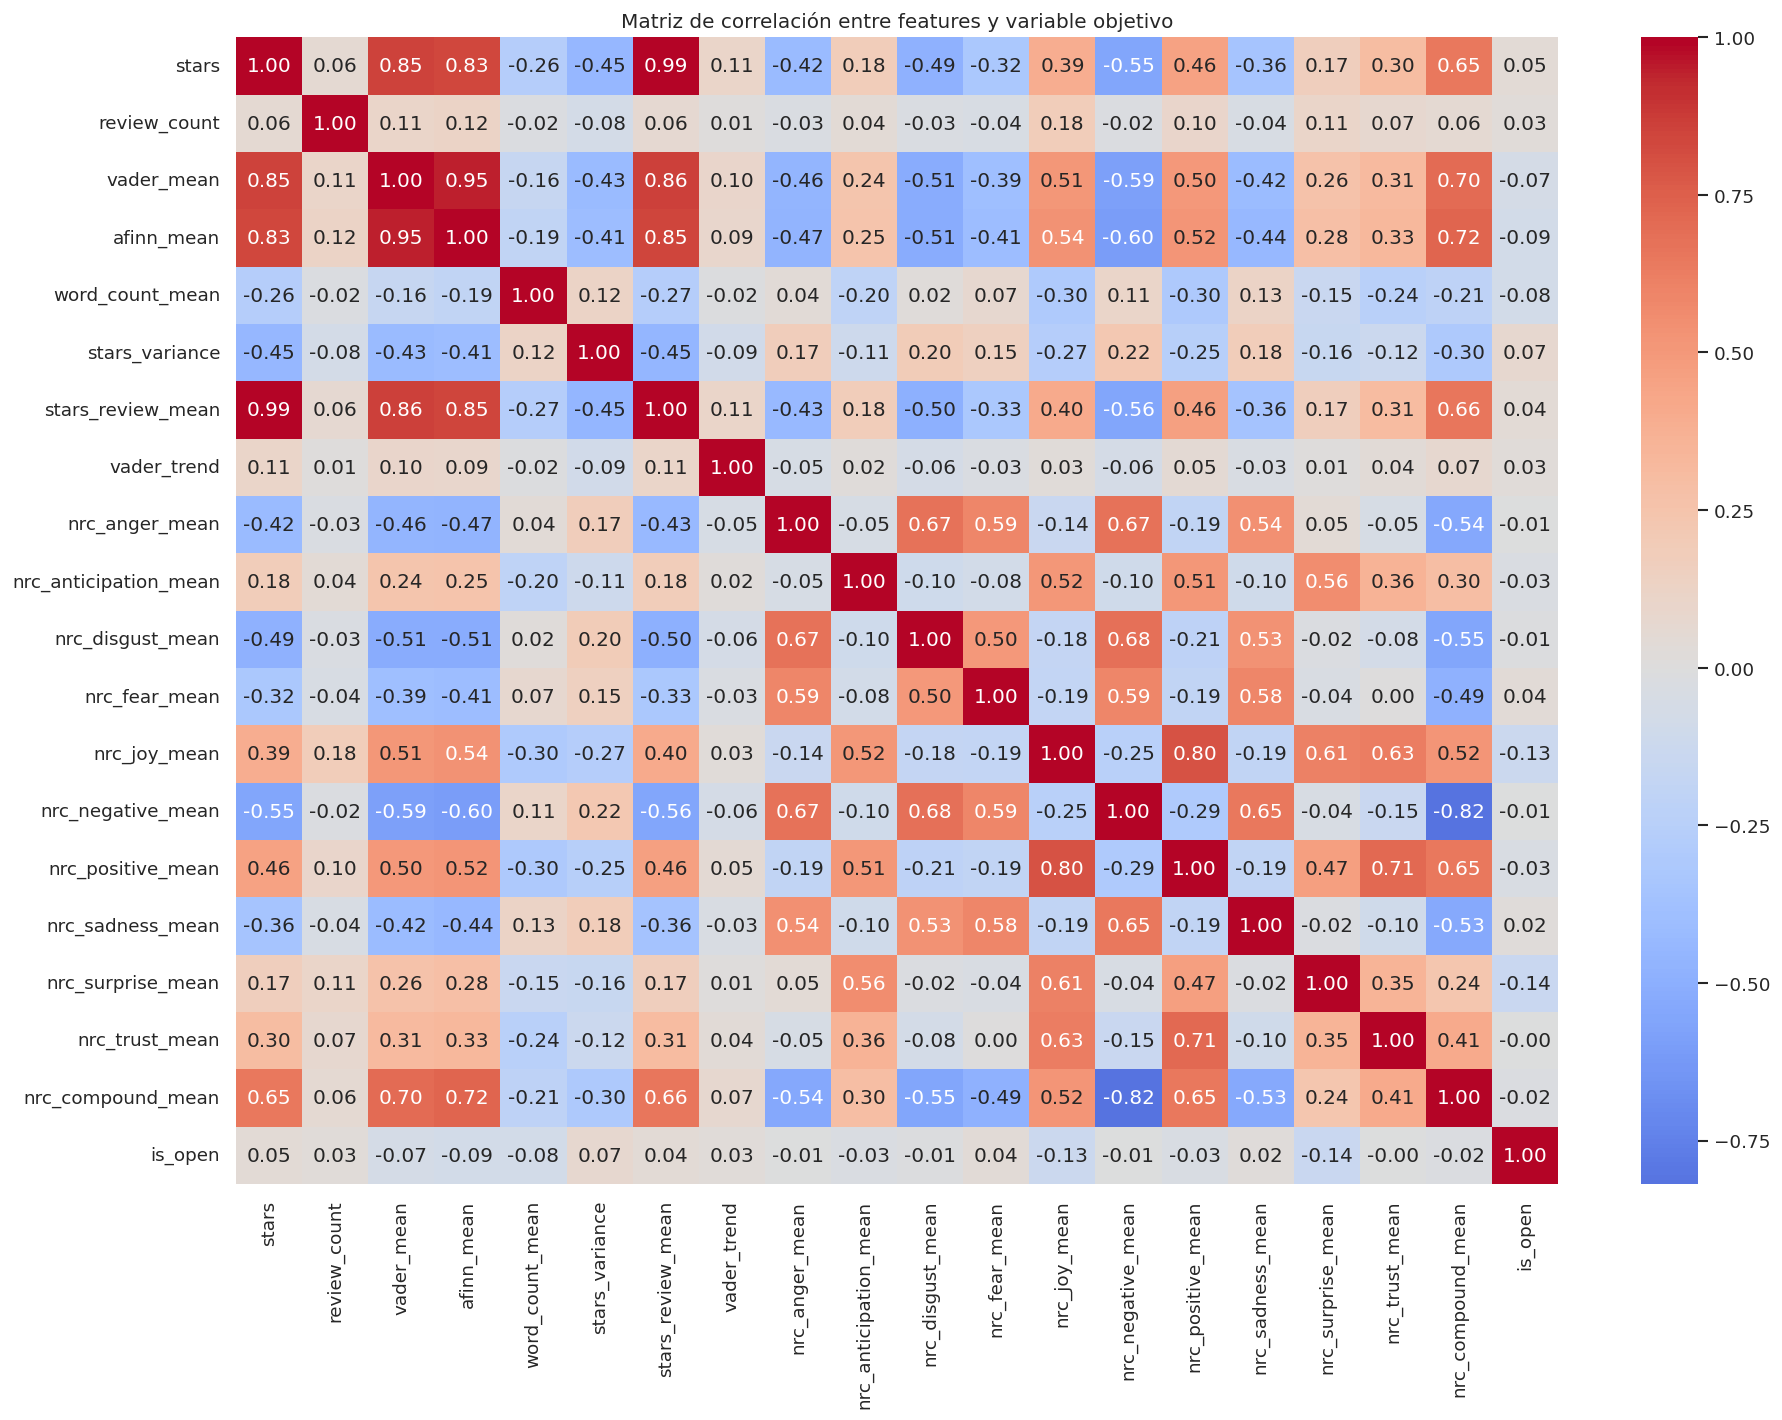


Correlación con is_open (ordenada):
stars_variance           0.072271
stars                    0.045529
stars_review_mean        0.044177
nrc_fear_mean            0.035655
review_count             0.029729
vader_trend              0.029547
nrc_sadness_mean         0.021578
nrc_trust_mean          -0.002389
nrc_anger_mean          -0.005848
nrc_negative_mean       -0.006708
nrc_disgust_mean        -0.013259
nrc_compound_mean       -0.019070
nrc_anticipation_mean   -0.029588
nrc_positive_mean       -0.033738
vader_mean              -0.071757
word_count_mean         -0.084268
afinn_mean              -0.086325
nrc_joy_mean            -0.129005
nrc_surprise_mean       -0.136922


In [29]:
numeric_cols = [
    'stars', 'review_count',
    'vader_mean', 'afinn_mean',
    'word_count_mean', 'stars_variance',
    'stars_review_mean', 'vader_trend',
] + nrc_mean_cols + ['is_open']

corr_matrix = df_pd[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Matriz de correlación entre features y variable objetivo')
plt.tight_layout()
plt.show()

print('\nCorrelación con is_open:')
print(corr_matrix['is_open'].drop('is_open').sort_values(ascending=False).to_string())

In [39]:
print('\nTop 20 ciudades por número de negocios:')
print(df_model.group_by('city').len().sort('len', descending=True).head(20))

from collections import Counter
todas_cats = (
    df_model['categories'].drop_nulls().str.split(', ').explode().to_list()
)
conteo_cats = Counter(todas_cats)
print(f'\nCategorías únicas reales: {len(conteo_cats):,}')
print('\nTop 30 categorías más frecuentes:')
for cat, count in conteo_cats.most_common(30):
    print(f'  {cat:<35} {count:>8,}')


Top 20 ciudades por número de negocios:
shape: (20, 2)
┌────────────────┬───────┐
│ city           ┆ len   │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Philadelphia   ┆ 14560 │
│ Tucson         ┆ 9244  │
│ Tampa          ┆ 9042  │
│ Indianapolis   ┆ 7537  │
│ Nashville      ┆ 6969  │
│ …              ┆ …     │
│ Wilmington     ┆ 1444  │
│ Franklin       ┆ 1414  │
│ St. Louis      ┆ 1255  │
│ St. Petersburg ┆ 1185  │
│ Meridian       ┆ 1043  │
└────────────────┴───────┘

Categorías únicas reales: 1,311

Top 30 categorías más frecuentes:
  Restaurants                           52,268
  Food                                  27,781
  Shopping                              24,395
  Home Services                         14,356
  Beauty & Spas                         14,292
  Nightlife                             12,281
  Health & Medical                      11,890
  Local Services                        11,198
  Bars                                  1

In [38]:
df_pd_final = df_model.to_pandas()

state_dummies = pd.get_dummies(df_pd_final['state'], prefix='state')

top_cats = [cat for cat, _ in conteo_cats.most_common(30)]
cats_lists = df_model['categories'].fill_null('').str.split(', ').to_list()

mlb = MultiLabelBinarizer(classes=top_cats)
cat_matrix = mlb.fit_transform(cats_lists)
cat_col_names = [f'cat_{c.replace(" ", "_").replace("&", "and").replace("(", "").replace(")", "")}' for c in top_cats]

df_cats = pd.DataFrame(cat_matrix, columns=cat_col_names)

df_final = pd.concat([
    df_pd_final[[
        'business_id', 'is_open',
        'stars', 'review_count',
        'vader_mean', 'afinn_mean',
        'word_count_mean', 'stars_variance',
    ] + nrc_mean_cols],
    state_dummies,
    df_cats,
], axis=1)

df_final = df_final.dropna(subset=['stars', 'review_count', 'vader_mean', 'afinn_mean', 'word_count_mean', 'stars_variance'] + nrc_mean_cols)

print(f'Shape del dataset final: {df_final.shape}')
print(f'Columnas: {df_final.columns.tolist()}')

os.makedirs('../data/csv', exist_ok=True)
output_path = '../data/csv/business_features.csv'
df_final.to_csv(output_path, index=False)
print(f'\nDataset guardado en: {output_path}')

/home/javclamar/Projects/tfg-sentiment-analysis/venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['& Probates', '3D Printing', 'ATV Rentals/Tours', 'Acai Bowls', 'Accessories', 'Accountants', 'Acne Treatment', 'Acupuncture', 'Addiction Medicine', 'Adoption Services', 'Adult', 'Adult Education', 'Adult Entertainment', 'Advertising', 'Aerial Fitness', 'Aerial Tours', 'Aestheticians', 'Afghan', 'African', 'Air Duct Cleaning', 'Aircraft Dealers', 'Aircraft Repairs', 'Airlines', 'Airport Lounges', 'Airport Shuttles', 'Airport Terminals', 'Airports', 'Airsoft', 'Allergists', 'Alternative Medicine', 'Amateur Sports Teams', 'Amusement Parks', 'Anesthesiologists', 'Animal Assisted Therapy', 'Animal Physical Therapy', 'Animal Shelters', 'Antiques', 'Apartment Agents', 'Apartments', 'Appliances', 'Appliances & Repair', 'Appraisal Services', 'Aquarium Services', 'Aquariums', 'Arabic', 'Arcades', 'Archery', 'Architects', 'Architectural Tours', '

Shape del dataset final: (150243, 76)
Columnas: ['business_id', 'is_open', 'stars', 'review_count', 'vader_mean', 'afinn_mean', 'word_count_mean', 'stars_variance', 'nrc_anger_mean', 'nrc_anticipation_mean', 'nrc_disgust_mean', 'nrc_fear_mean', 'nrc_joy_mean', 'nrc_negative_mean', 'nrc_positive_mean', 'nrc_sadness_mean', 'nrc_surprise_mean', 'nrc_trust_mean', 'nrc_compound_mean', 'state_AB', 'state_AZ', 'state_CA', 'state_CO', 'state_DE', 'state_FL', 'state_HI', 'state_ID', 'state_IL', 'state_IN', 'state_LA', 'state_MA', 'state_MI', 'state_MO', 'state_MT', 'state_NC', 'state_NJ', 'state_NV', 'state_PA', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VI', 'state_VT', 'state_WA', 'state_XMS', 'cat_Restaurants', 'cat_Food', 'cat_Shopping', 'cat_Home_Services', 'cat_Beauty_and_Spas', 'cat_Nightlife', 'cat_Health_and_Medical', 'cat_Local_Services', 'cat_Bars', 'cat_Automotive', 'cat_Event_Planning_and_Services', 'cat_Sandwiches', 'cat_American_Traditional', 'cat_Active_Life', 'cat_P